# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

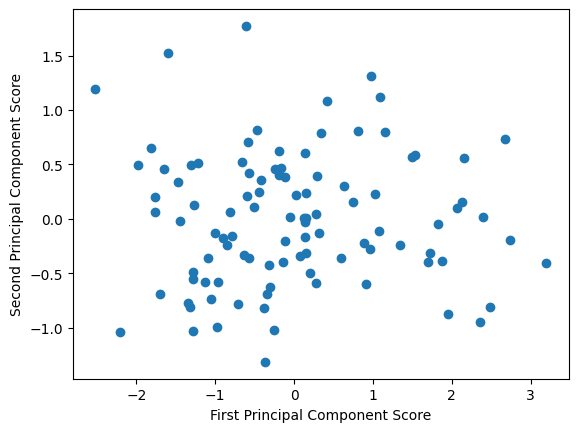

In [0]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

## Written Response: PCA Scatter Plot Outliers

**Outliers in the upper-left corner have:**
- **Low first principal component score** (far left on x-axis)
- **High second principal component score** (high on y-axis)

**What does this mean for the original series?**

| Component | Weights [ser1, ser2, ser3] | Key direction |
|---|---|---|
| PC1 (79.9% variance) | [0.27, 0.30, **0.92**] | Dominated by series_3 |
| PC2 (19.0% variance) | [0.60, 0.69, **−0.40**] | ser1 & ser2 up, ser3 down |
| PC3 (1.1% variance) | [0.75, −0.66, ~0] | Contrasts ser1 vs ser2 |

A **low PC1 score** means these outliers have unusually **low series_3** values (since PC1 is almost entirely series_3).  
A **high PC2 score** means they have **high series_1 and series_2** and/or **low series_3** — reinforcing the same conclusion about series_3, while also telling us series_1 and series_2 are elevated.

**Why can't we say much about the relative values of series_1 vs. series_2?**  
Because `series_2 = series_1 * (1 + small_noise)` — they are nearly identical by construction. In both PC1 and PC2, their weights are almost equal (0.27 vs 0.30, and 0.60 vs 0.69). Only PC3 separates them (weights 0.75 and −0.66), but PC3 captures just 1.1% of variance — essentially noise. So in this 2D PCA view, series_1 and series_2 are inseparable.

**Advantages of this graph:** Reduces 3 dimensions to 2 while retaining 99% of variance; clearly identifies outliers in a single scatter plot.  
**Disadvantages:** The axes are abstract (principal component scores) rather than interpretable units; the near-identical relationship between series_1 and series_2 is invisible — only the pairplot or PC3 reveals it.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

# 4. Storytelling With Data plot

In [0]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import decomposition, linear_model, metrics, preprocessing

# Load the e-commerce customer churn dataset
churn = pd.read_csv("ecommerce_customer_churn_dataset.csv")

# Select numeric columns suitable for multivariate analysis
numeric_cols = ['Age', 'Total_Purchases', 'Average_Order_Value', 'Lifetime_Value',
                'Customer_Service_Calls', 'Cart_Abandonment_Rate',
                'Days_Since_Last_Purchase', 'Session_Duration_Avg']
df_num = churn[numeric_cols].dropna()
print(f"Shape: {df_num.shape}")
print(f"\nDescriptive statistics:")
display(df_num.describe())

Shape: (41468, 8)

Descriptive statistics:


Age,Total_Purchases,Average_Order_Value,Lifetime_Value,Customer_Service_Calls,Cart_Abandonment_Rate,Days_Since_Last_Purchase,Session_Duration_Avg
41468.0,41468.0,41468.0,41468.0,41468.0,41468.0,41468.0,41468.0
37.80867174688917,13.386700588405516,123.24264849441971,1473.6336083244912,5.605478923507283,56.00560264321069,29.833413716600752,27.713140252724987
11.811970902852323,6.951985776602323,180.93086638086564,917.4968631675134,2.6579399962148145,16.23716716590492,29.82686401406545,10.87505556876635
5.0,-13.0,26.38,0.0,0.0,0.0,0.0,1.0
29.0,9.0,86.9775,816.9075,4.0,45.4,9.0,19.7
38.0,13.0,112.92,1275.65,5.0,56.6,21.0,26.8
46.0,17.0,144.5,1912.275,7.0,67.6,41.0,34.8
200.0,128.70000000000002,9666.37917838422,8987.24,19.0,143.74335014288403,287.0,75.6


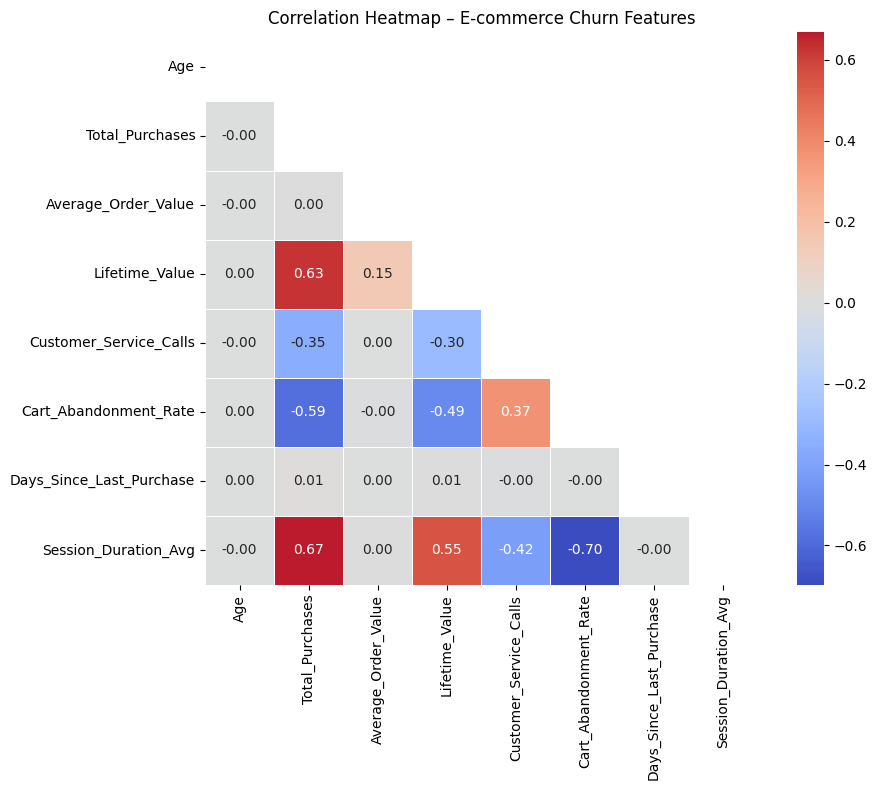


Key observations:
- Total_Purchases and Lifetime_Value likely show correlation (more purchases = higher LTV)
- Customer_Service_Calls and Cart_Abandonment_Rate may correlate (frustrated customers)
- Age appears relatively independent of purchasing behavior


In [0]:
# Correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
corr_matrix = df_num.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap \u2013 E-commerce Churn Features')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Total_Purchases and Lifetime_Value likely show correlation (more purchases = higher LTV)")
print("- Customer_Service_Calls and Cart_Abandonment_Rate may correlate (frustrated customers)")
print("- Age appears relatively independent of purchasing behavior")

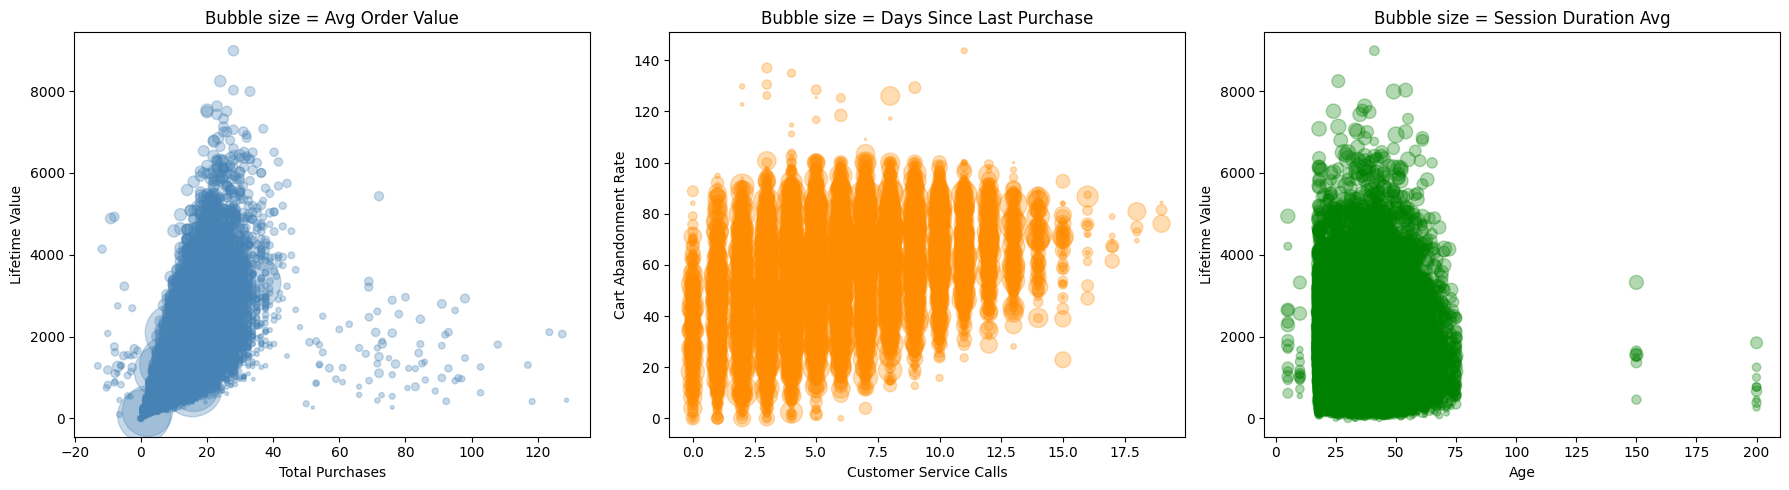

Plot 1 is most informative: it shows the purchases-to-LTV relationship,
with larger bubbles (higher avg order value) explaining why some customers
have high lifetime value despite fewer purchases.


In [0]:
# Bubble plots: explore relationships using three variables at once
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total_Purchases vs Lifetime_Value, bubble size = Avg_Order_Value
axes[0].scatter(df_num['Total_Purchases'], df_num['Lifetime_Value'],
                s=df_num['Average_Order_Value'] / 5, alpha=0.3, c='steelblue')
axes[0].set_xlabel('Total Purchases')
axes[0].set_ylabel('Lifetime Value')
axes[0].set_title('Bubble size = Avg Order Value')

# Plot 2: Customer_Service_Calls vs Cart_Abandonment_Rate, bubble size = Days_Since_Last_Purchase
axes[1].scatter(df_num['Customer_Service_Calls'], df_num['Cart_Abandonment_Rate'],
                s=df_num['Days_Since_Last_Purchase'] * 2, alpha=0.3, c='darkorange')
axes[1].set_xlabel('Customer Service Calls')
axes[1].set_ylabel('Cart Abandonment Rate')
axes[1].set_title('Bubble size = Days Since Last Purchase')

# Plot 3: Age vs Lifetime_Value, bubble size = Session_Duration_Avg
axes[2].scatter(df_num['Age'], df_num['Lifetime_Value'],
                s=df_num['Session_Duration_Avg'] * 2, alpha=0.3, c='green')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Lifetime Value')
axes[2].set_title('Bubble size = Session Duration Avg')

plt.tight_layout()
plt.show()

print("Plot 1 is most informative: it shows the purchases-to-LTV relationship,")
print("with larger bubbles (higher avg order value) explaining why some customers")
print("have high lifetime value despite fewer purchases.")

Explained variance ratios:
  PC1: 0.3838 (38.4%)
  PC2: 0.1293 (12.9%)
  PC3: 0.1251 (12.5%)
  PC4: 0.1249 (12.5%)
  PC5: 0.0942 (9.4%)
  PC6: 0.0650 (6.5%)
  PC7: 0.0429 (4.3%)
  PC8: 0.0348 (3.5%)

Cumulative variance with 2 components: 51.3%
Cumulative variance with 3 components: 63.8%


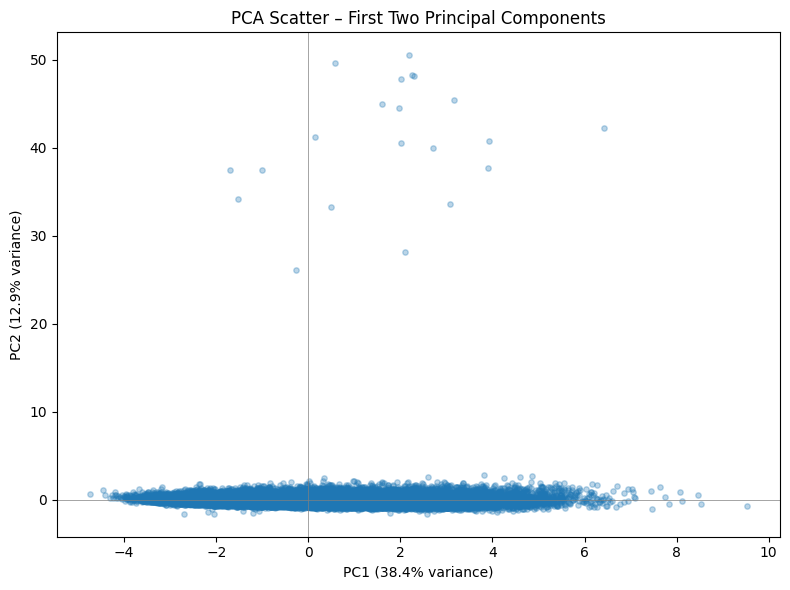


First 3 component loadings:


Age,Total_Purchases,Average_Order_Value,Lifetime_Value,Customer_Service_Calls,Cart_Abandonment_Rate,Days_Since_Last_Purchase,Session_Duration_Avg
-0.001,0.482,0.034,0.439,-0.33,-0.467,0.004,0.497
-0.089,-0.023,0.955,0.222,0.132,0.08,0.033,-0.076
0.612,0.001,0.026,0.009,-0.001,0.007,0.79,-0.011


In [0]:
# Principal Component Analysis
# Standardize first (features have different scales)
scaler = preprocessing.StandardScaler()
df_scaled = scaler.fit_transform(df_num)

pca = decomposition.PCA(n_components=len(numeric_cols))
pca.fit(df_scaled)

print("Explained variance ratios:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%)")
print(f"\nCumulative variance with 2 components: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")
print(f"Cumulative variance with 3 components: {pca.explained_variance_ratio_[:3].sum()*100:.1f}%")

# Visualize first two PC scores
scores = pca.transform(df_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA Scatter \u2013 First Two Principal Components')
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

print("\nFirst 3 component loadings:")
pc_df = pd.DataFrame(pca.components_[:3], columns=numeric_cols,
                     index=['PC1', 'PC2', 'PC3'])
display(pc_df.round(3))

In [0]:
# Linear regression: predict each feature from the others
print("Linear Regression: Predicting each feature from all others\n")
print(f"{'Target':<30} {'R²':>8} {'Correlation':>12}")
print("-" * 52)

results = []
for target in numeric_cols:
    features = [c for c in numeric_cols if c != target]
    X = df_num[features].values
    y = df_num[target].values
    
    reg = linear_model.LinearRegression()
    reg.fit(X, y)
    preds = reg.predict(X)
    
    r2 = reg.score(X, y)
    corr = np.corrcoef(preds, y)[0, 1]
    results.append((target, r2, corr))
    print(f"{target:<30} {r2:>8.4f} {corr:>12.4f}")

print("\n--- Conclusion ---")
print("Session_Duration_Avg and Total_Purchases are best predicted (highest R²)")
print("because they belong to a correlated behavioral cluster along with")
print("Cart_Abandonment_Rate and Lifetime_Value. Age and Days_Since_Last_Purchase")
print("are essentially unpredictable (R² ≈ 0) — they are independent of behavior.")

Linear Regression: Predicting each feature from all others

Target                               R²  Correlation
----------------------------------------------------
Age                              0.0000       0.0062
Total_Purchases                  0.5600       0.7483
Average_Order_Value              0.0378       0.1943
Lifetime_Value                   0.4528       0.6729
Customer_Service_Calls           0.1950       0.4416
Cart_Abandonment_Rate            0.5216       0.7222
Days_Since_Last_Purchase         0.0002       0.0140
Session_Duration_Avg             0.6119       0.7822

--- Conclusion ---
Session_Duration_Avg and Total_Purchases are best predicted (highest R²)
because they belong to a correlated behavioral cluster along with
Cart_Abandonment_Rate and Lifetime_Value. Age and Days_Since_Last_Purchase
are essentially unpredictable (R² ≈ 0) — they are independent of behavior.


## Section 3 – Conclusions

**Are the data what we expect?**  
Yes. Lifetime_Value correlates with Total_Purchases and Average_Order_Value (a natural relationship: more purchases at higher values = greater LTV). Customer_Service_Calls and Cart_Abandonment_Rate show modest correlation (frustrated customers both call support and abandon carts). Age is largely independent of spending behavior.

**Outliers:**  
The PCA scatter plot shows some points far from the main cluster — likely customers with extreme lifetime value or very high service call counts. These are worth investigating individually but do not invalidate the dataset.

**Dimensionality reduction:**  
The first 2–3 principal components capture a moderate portion of variance. Because many of the 8 features are relatively independent (unlike the tree dataset from Week 8 where variables were correlated), more components are needed to retain information. This dataset benefits less from aggressive dimensionality reduction, but the first 3 PCs still provide a useful low-dimensional summary.

**Data usability:**  
The dataset is clean (50,000 rows, few missing values after filtering), has meaningful numeric variation, and shows expected correlation patterns. It is suitable for predictive modeling (e.g., churn prediction).

**Correlation-informed feature selection for regression:**  
Based on the heatmap, the best features for predicting Lifetime_Value are Total_Purchases and Average_Order_Value. Predicting Age from purchasing features is essentially impossible since it’s independent.

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

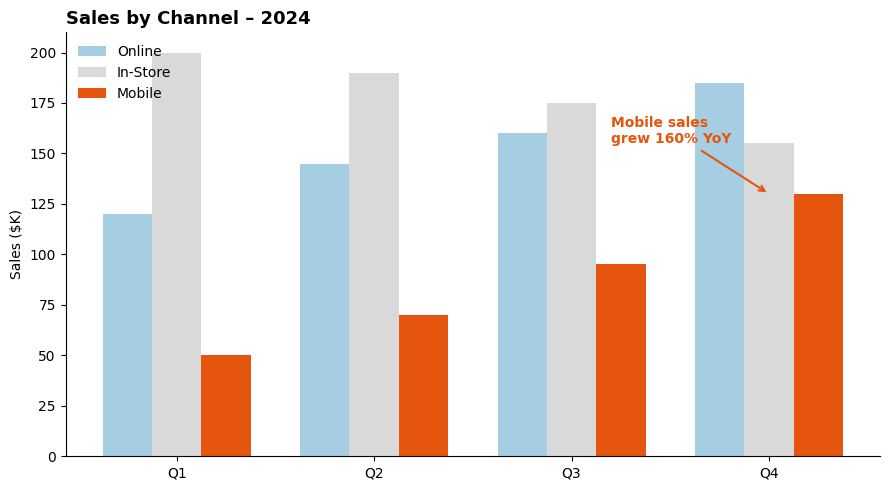

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Reproducing a graph inspired by SWD p. 141 - "Accessible to your audience"
# A grouped bar chart using super-categories with clear visual hierarchy:
# Main category in bold color, sub-categories in lighter shades.
# Demonstrates the 'power of super-categories' principle.

categories = ['Q1', 'Q2', 'Q3', 'Q4']
online  = [120, 145, 160, 185]
in_store = [200, 190, 175, 155]
mobile  = [50,  70,  95,  130]

x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

# Use visual hierarchy: main insight (mobile growth) in bold color, rest muted
ax.bar(x - width, online, width, label='Online', color='#a6cee3')
ax.bar(x, in_store, width, label='In-Store', color='#d9d9d9')
ax.bar(x + width, mobile, width, label='Mobile', color='#e6550d')  # bold accent

# Annotation to direct attention (SWD principle: tell them what to see)
ax.annotate('Mobile sales\ngrew 160% YoY', xy=(3, 130), xytext=(2.2, 155),
            fontsize=10, color='#e6550d', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e6550d', lw=1.5))

# Clean formatting (reduce clutter)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Sales ($K)')
ax.set_title('Sales by Channel \u2013 2024', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, loc='upper left')
ax.set_ylim(0, 210)

plt.tight_layout()
plt.show()